num samples: 50
idx: 2 org: (128, 128, 3) uint8 new: (128, 128, 3) uint8


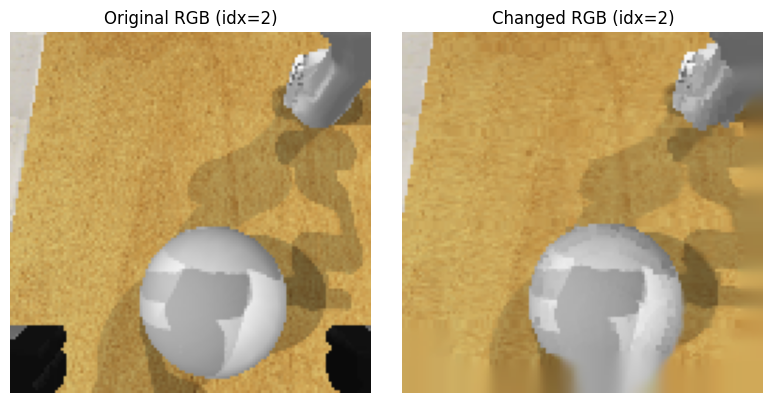

In [147]:
import io
import random
import lmdb
import numpy as np
import matplotlib.pyplot as plt

lmdb_path = "/home/zsh/dcoda/D-Aug/data/tst.lmdb"

env = lmdb.open(
    lmdb_path,
    readonly=True,
    lock=False,
    readahead=False,
    meminit=False,
)

with env.begin(write=False) as txn:
    # 找到所有 original 样本编号
    idxs = []
    for k, _ in txn.cursor():
        ks = k.decode()
        if ks.endswith("_original_rgb"):
            idxs.append(int(ks[4:9]))  # "data00012_original_rgb" -> 12

    idxs = sorted(set(idxs))
    print(f"num samples: {len(idxs)}")

    # 随机看一条
    i = random.choice(idxs)

    k_org = f"data{i:05d}_original_rgb".encode()
    k_new = f"data{i:05d}_changed_rgb".encode()

    v_org = txn.get(k_org)
    v_new = txn.get(k_new)

    if v_org is None or v_new is None:
        raise ValueError(f"Missing key pair for idx={i}")

    img_org = np.load(io.BytesIO(v_org), allow_pickle=False)
    img_new = np.load(io.BytesIO(v_new), allow_pickle=False)

print("idx:", i, "org:", img_org.shape, img_org.dtype, "new:", img_new.shape, img_new.dtype)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title(f"Original RGB (idx={i})")
plt.imshow(img_org)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Changed RGB (idx={i})")
plt.imshow(img_new)
plt.axis("off")

plt.tight_layout()
plt.show()